In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

#  #Read fresh data
# df = pd.read_csv('/content/drive/MyDrive/Data/Test/full_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/data/full_data.csv')

In [7]:
# Shape
print("Shape:", df.shape)

Shape: (199523, 43)


In [8]:
df = df.drop(columns=['Unnamed: 0'])

In [9]:
df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)).strip('_') for c in df.columns]

In [10]:
# Check for Null Values in the Columns , so that we can take care of that
print(df.isnull().sum())

age                                             0
class_of_worker                                 0
detailed_industry_recode                        0
detailed_occupation_recode                      0
education                                       0
wage_per_hour                                   0
enroll_in_edu_inst_last_wk                      0
marital_stat                                    0
major_industry_code                             0
major_occupation_code                           0
race                                            0
hispanic_origin                               874
sex                                             0
member_of_a_labor_union                         0
reason_for_unemployment                         0
full_or_part_time_employment_stat               0
capital_gains                                   0
capital_losses                                  0
dividends_from_stocks                           0
tax_filer_stat                                  0


In [11]:
# As ? is also Null value in census data , we must check fo it and handle
print((df == '?').sum())

age                                               0
class_of_worker                                   0
detailed_industry_recode                          0
detailed_occupation_recode                        0
education                                         0
wage_per_hour                                     0
enroll_in_edu_inst_last_wk                        0
marital_stat                                      0
major_industry_code                               0
major_occupation_code                             0
race                                              0
hispanic_origin                                   0
sex                                               0
member_of_a_labor_union                           0
reason_for_unemployment                           0
full_or_part_time_employment_stat                 0
capital_gains                                     0
capital_losses                                    0
dividends_from_stocks                             0
tax_filer_st

In [12]:
##im replacing all the ? to Null. so that all misising values are in one format
df = df.replace('?', np.nan)

In [13]:
##there are 9 total columns with Null values
print(df.isnull().sum())

age                                               0
class_of_worker                                   0
detailed_industry_recode                          0
detailed_occupation_recode                        0
education                                         0
wage_per_hour                                     0
enroll_in_edu_inst_last_wk                        0
marital_stat                                      0
major_industry_code                               0
major_occupation_code                             0
race                                              0
hispanic_origin                                 874
sex                                               0
member_of_a_labor_union                           0
reason_for_unemployment                           0
full_or_part_time_employment_stat                 0
capital_gains                                     0
capital_losses                                    0
dividends_from_stocks                             0
tax_filer_st

We can See that the value counts in all these columns look almost identical hence, lets analyze one column on how its related to our target variable

Here we can see that most of the

In [14]:
# MISSING VALUE ANALYSIS
null_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
null_cols = null_pct[null_pct > 0]

print(f'Columns with missing values: {len(null_cols)} out of {df.shape[1]}\n')
print('=== Missing value breakdown ===\n')
for col, pct in null_cols.items():
    count = df[col].isna().sum()
    print(f'  {col:45s} {count:>7,}  ({pct:.2f}%)')

Columns with missing values: 9 out of 42

=== Missing value breakdown ===

  migration_prev_res_in_sunbelt                  99,696  (49.97%)
  migration_code_change_in_msa                   99,696  (49.97%)
  migration_code_change_in_reg                   99,696  (49.97%)
  migration_code_move_within_reg                 99,696  (49.97%)
  country_of_birth_father                         6,713  (3.36%)
  country_of_birth_mother                         6,119  (3.07%)
  country_of_birth_self                           3,393  (1.70%)
  hispanic_origin                                   874  (0.44%)
  state_of_previous_residence                       708  (0.35%)


In [15]:
migration_cols = [
    'migration_code_change_in_msa',
    'migration_code_change_in_reg',
    'migration_code_move_within_reg',
    'migration_prev_res_in_sunbelt',
]
missing_mask = df[migration_cols].isna()
all_four_missing = missing_mask.all(axis=1).sum()
none_missing = (~missing_mask).all(axis=1).sum()
print(f'All 4 missing: {all_four_missing:,} rows ({all_four_missing/len(df)*100:.1f}%)')

All 4 missing: 99,696 rows (50.0%)


Here we can see that they are missing values for the same column, and most of the values in this columsn are null hence we can drop these columns

In [16]:
migration_drop = [
    'migration_code_change_in_msa',
    'migration_code_change_in_reg',
    'migration_code_move_within_reg',
    'migration_prev_res_in_sunbelt',
]

df = df.drop(columns=migration_drop)

In [17]:
len(df.columns)

38

In [18]:
missing_nan_categorical = [
    'country_of_birth_father',
    'country_of_birth_mother',
    'country_of_birth_self',
    'hispanic_origin',
    'state_of_previous_residence',
]

for col in missing_nan_categorical:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:

##there are no null values in the data now
print(df.isnull().sum())

age                                           0
class_of_worker                               0
detailed_industry_recode                      0
detailed_occupation_recode                    0
education                                     0
wage_per_hour                                 0
enroll_in_edu_inst_last_wk                    0
marital_stat                                  0
major_industry_code                           0
major_occupation_code                         0
race                                          0
hispanic_origin                               0
sex                                           0
member_of_a_labor_union                       0
reason_for_unemployment                       0
full_or_part_time_employment_stat             0
capital_gains                                 0
capital_losses                                0
dividends_from_stocks                         0
tax_filer_stat                                0
region_of_previous_residence            

In [20]:
#Lets CLean the Label column
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
df['label'] = df['label'].str.strip()
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})

print(df['label'].value_counts())

label
0    187141
1     12382
Name: count, dtype: int64


In [21]:
##lets check the duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3356


In [22]:

df = df.drop_duplicates(keep='first')

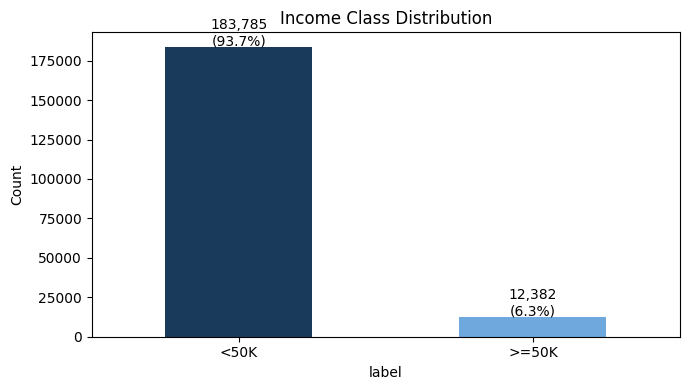

In [23]:
# 4.1 TARGET CLASS DISTRIBUTION
counts = df['label'].value_counts()
pcts = df['label'].value_counts(normalize=True) * 100



fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax, color=['#1a3a5c', '#6fa8dc'])
ax.set_title('Income Class Distribution')
ax.set_xticklabels(['<50K', '>=50K'], rotation=0)
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 1000, f'{v:,}\n({pcts.iloc[i]:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

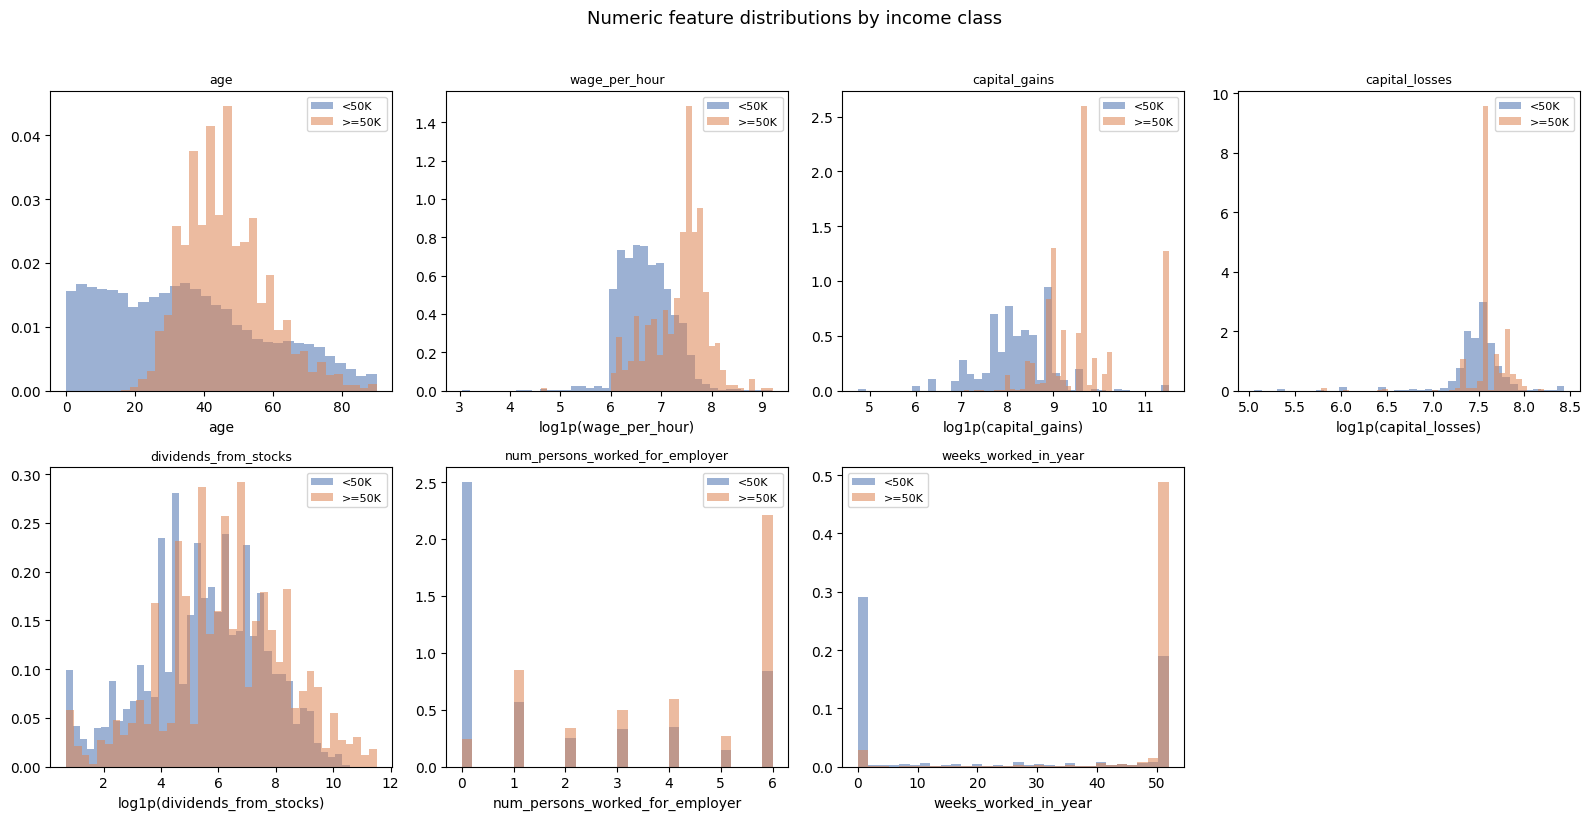

In [24]:
# Key numeric features — distributions split by income class
key_num = ['age', 'wage_per_hour', 'capital_gains', 'capital_losses',
           'dividends_from_stocks', 'num_persons_worked_for_employer',
           'weeks_worked_in_year']
# Keep only columns that exist
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, c in enumerate(key_num):
    ax = axes[i // 4, i % 4]
    for lbl, color, name in [(0, '#4C72B0', '<50K'), (1, '#DD8452', '>=50K')]:
        data = df[df['label'] == lbl][c]
        # Log-scale for heavily skewed financial columns
        if c in ['capital_gains', 'capital_losses', 'dividends_from_stocks', 'wage_per_hour']:
            data = data[data > 0]
            if len(data):
                ax.hist(np.log1p(data), bins=40, alpha=0.55, density=True,
                        label=name, color=color)
            ax.set_xlabel(f'log1p({c})')
        else:
            ax.hist(data, bins=30, alpha=0.55, density=True,
                    label=name, color=color)
            ax.set_xlabel(c)
    ax.legend(fontsize=8)
    ax.set_title(c, fontsize=9)

# Hide unused subplot
if len(key_num) < 8:
    axes[1, 3].axis('off')

plt.suptitle('Numeric feature distributions by income class', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

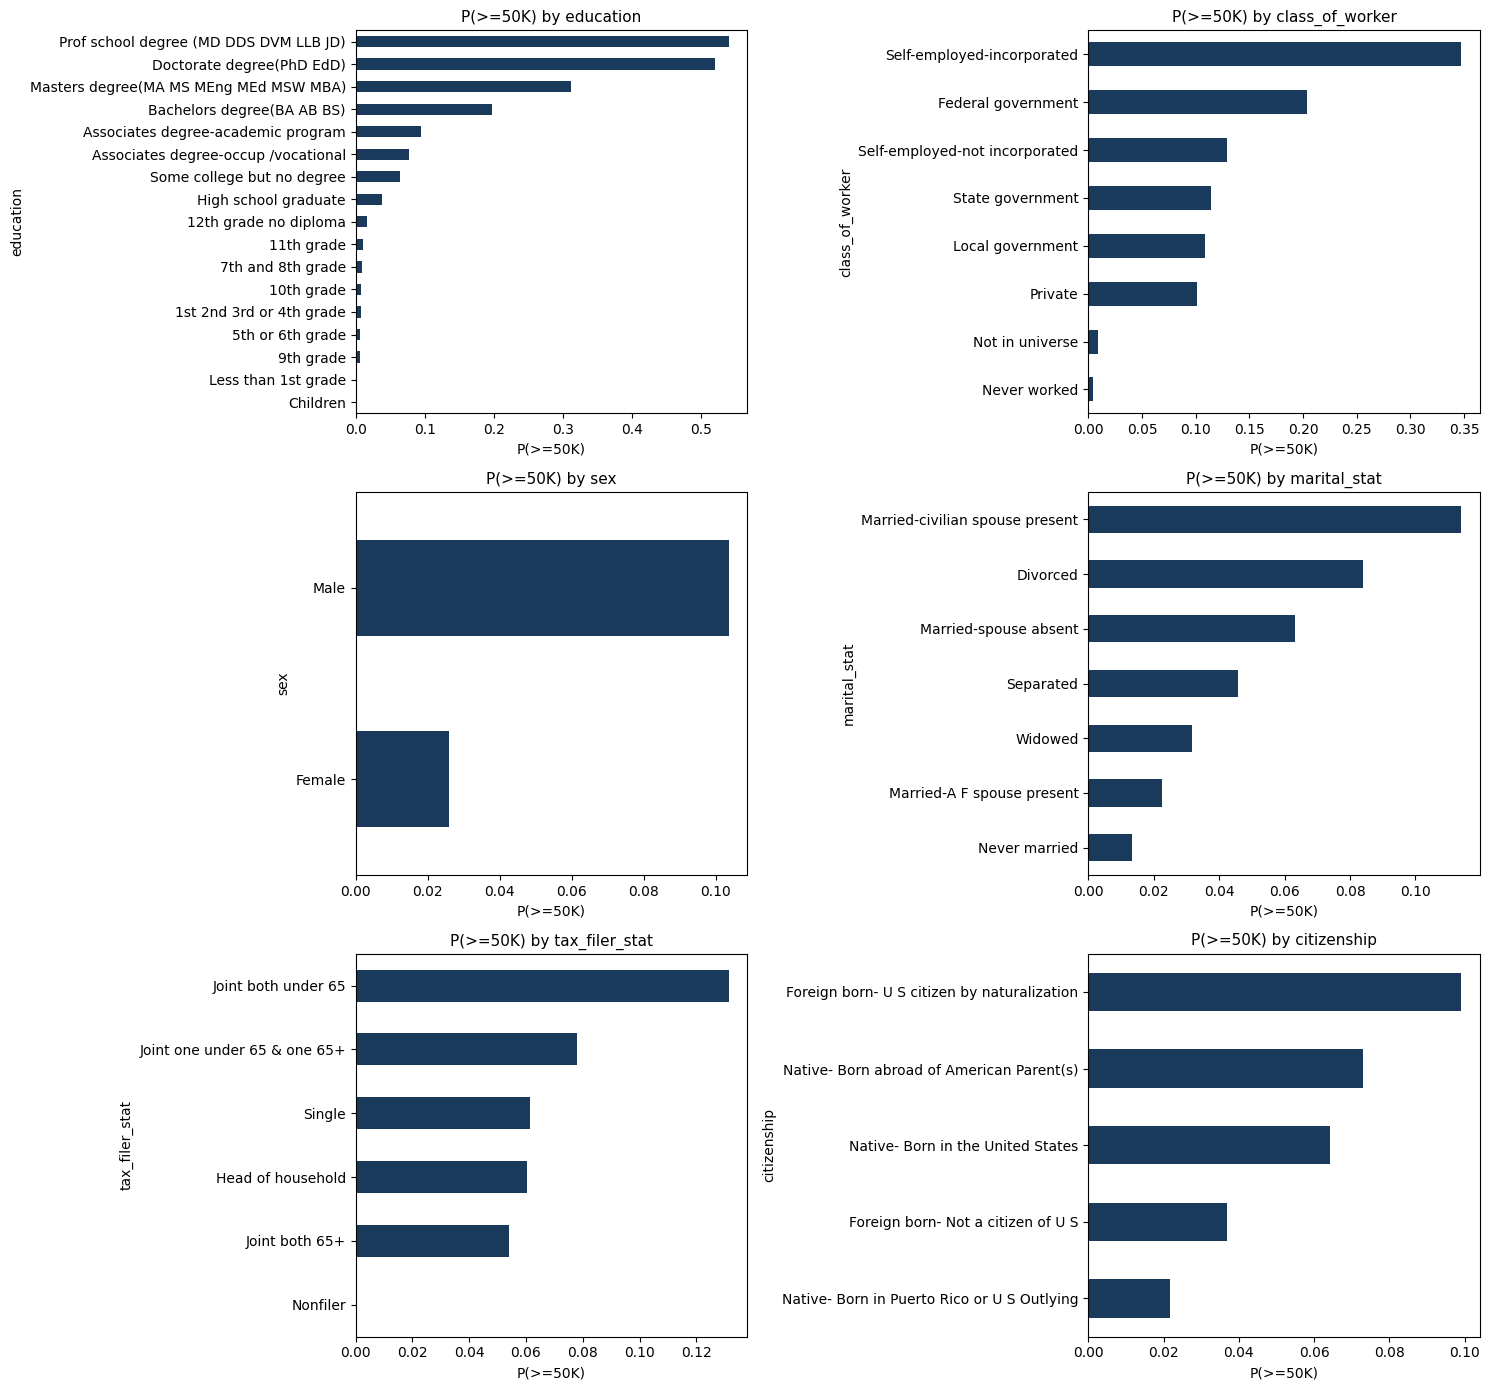

In [25]:
# 4.3 CATEGORICAL FEATURE ANALYSIS

cat_to_plot = ['education', 'class_of_worker', 'sex', 'marital_stat',
               'tax_filer_stat', 'citizenship']
cat_to_plot = [c for c in cat_to_plot if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for i, c in enumerate(cat_to_plot):
    ax = axes[i // 2, i % 2]
    rates = df.groupby(c, observed=True)['label'].agg(['mean', 'count'])
    rates = rates[rates['count'] > 200].sort_values('mean')
    rates['mean'].plot.barh(ax=ax, color='#1a3a5c')
    ax.set_title(f'P(>=50K) by {c}', fontsize=11)
    ax.set_xlabel('P(>=50K)')

plt.tight_layout()
plt.show()

In [26]:
# Which specific categories have the highest income rates?
print('=== Top 15 highest-income categories (min 500 people) ===\n')

all_cat = df.select_dtypes(include=['category', 'object']).columns.tolist()
high_income_cats = []

for c in all_cat:
    rates = df.groupby(c, observed=True)['label'].agg(['mean', 'count'])
    rates = rates[rates['count'] > 500]
    if len(rates) > 0:
        top = rates.sort_values('mean', ascending=False).head(1)
        high_income_cats.append({
            'feature': c,
            'category': top.index[0],
            'income_rate': round(top['mean'].values[0] * 100, 1),
            'count': int(top['count'].values[0]),
        })

if len(high_income_cats) > 0:
    top_cats = pd.DataFrame(high_income_cats).sort_values('income_rate', ascending=False).head(15)
    top_cats.columns = ['Feature', 'Top Category', 'Income Rate (%)', 'Count']
    print(top_cats.to_string(index=False))
else:
    print('No categorical columns found. Checking dtypes...')
    print(df.dtypes.value_counts())

=== Top 15 highest-income categories (min 500 people) ===

                                   Feature                                Top Category  Income Rate (%)  Count
                                 education      Prof school degree (MD DDS DVM LLB JD)             54.0   1793
                           class_of_worker                  Self-employed-incorporated             34.7   3264
                     major_occupation_code              Executive admin and managerial             28.8  12495
                       major_industry_code                                      Mining             25.9    563
        detailed_household_and_family_stat                                 Householder             14.7  53239
                   country_of_birth_mother                                       India             14.0    580
                   member_of_a_labor_union                                         Yes             13.6   3030
                   country_of_birth_father           

## 5. Feature Selection

### 5.1 Full-feature importance analysis
First, train a baseline model on ALL remaining features to identify which ones actually drive predictions.

In [27]:
# Convert all object columns to category dtype
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype('category')

print(f'Object columns remaining: {len(df.select_dtypes(include="object").columns)} (should be 0)')
print(f'\nDtype summary:')
print(df.dtypes.value_counts())

Object columns remaining: 0 (should be 0)

Dtype summary:
int64       13
category     3
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
float64      1
category     1
category     1
category     1
Name: count, dtype: int64


In [28]:
# Drop survey sampling weight
df = df.drop(columns=['weight'])
print(f'Dropped: weight')
print(f'Shape: {df.shape}')

Dropped: weight
Shape: (196167, 37)


In [29]:
# FOR FEATURE SELECTION LETS USE LIGHTGBM USING ALL THE FEATURES AND THEN CHOOSE THE TOP PERFORMING FEATURES

all_feature_cols = [c for c in df.columns if c != 'label']
all_cat = [c for c in all_feature_cols if df[c].dtype.name == 'category']

X_all = df[all_feature_cols]
y_all = df['label']

X_tr_all, X_val_all, y_tr_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

spw_all = (y_tr_all == 0).sum() / (y_tr_all == 1).sum()

baseline_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'scale_pos_weight': spw_all,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
}

ts_all = lgb.Dataset(X_tr_all, label=y_tr_all, categorical_feature=all_cat)
vs_all = lgb.Dataset(X_val_all, label=y_val_all, categorical_feature=all_cat, reference=ts_all)

model_baseline = lgb.train(
    baseline_params, ts_all,
    num_boost_round=500,
    valid_sets=[vs_all],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
)

print(f'Baseline PR-AUC: {model_baseline.best_score["valid_0"]["average_precision"]:.4f}')
print(f'Best iteration: {model_baseline.best_iteration}')

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[229]	valid_0's average_precision: 0.681471
Baseline PR-AUC: 0.6815
Best iteration: 229


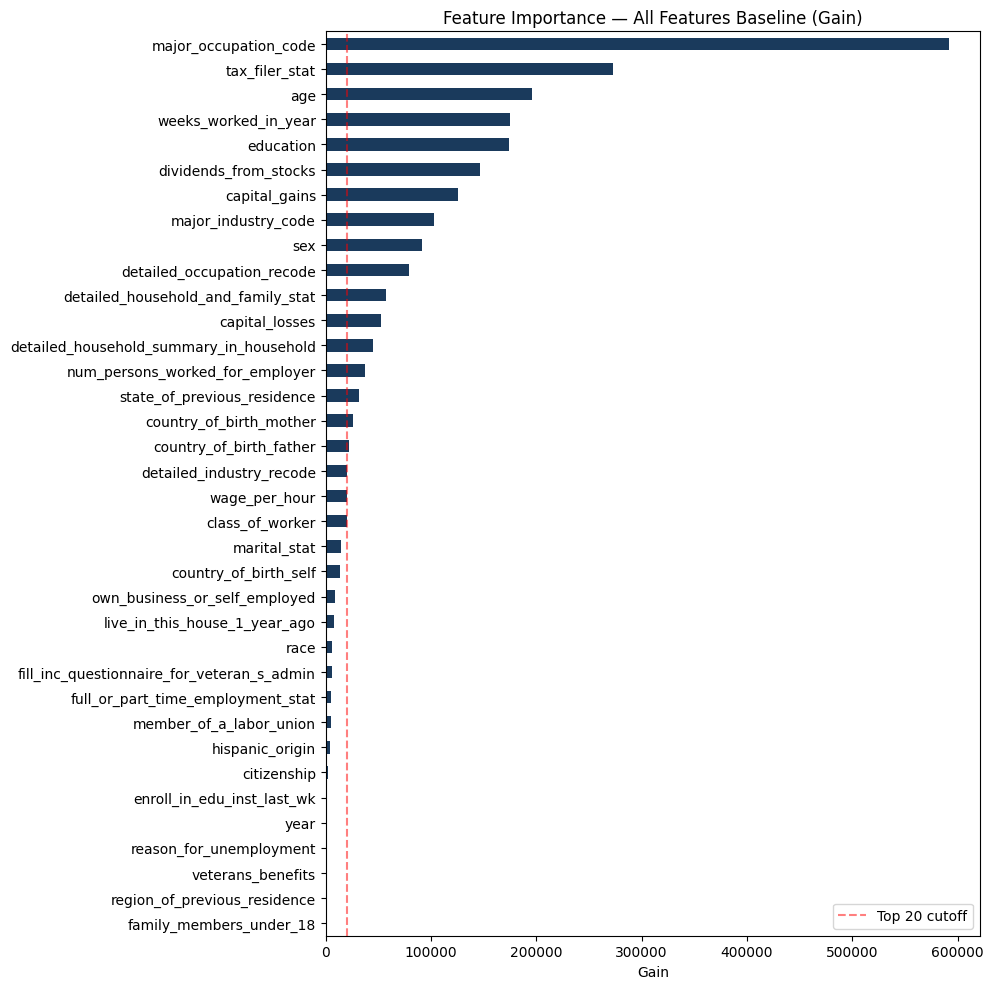

=== Feature importance ranking ===

   1.  ✓ major_occupation_code                              591,774  (25.1%)
   2.  ✓ tax_filer_stat                                     272,757  (11.6%)
   3.  ✓ age                                                196,137  (8.3%)
   4.  ✓ weeks_worked_in_year                               175,449  (7.4%)
   5.  ✓ education                                          173,764  (7.4%)
   6.  ✓ dividends_from_stocks                              146,073  (6.2%)
   7.  ✓ capital_gains                                      125,409  (5.3%)
   8.  ✓ major_industry_code                                102,679  (4.3%)
   9.  ✓ sex                                                 91,115  (3.9%)
  10.  ✓ detailed_occupation_recode                          79,173  (3.4%)
  11.  ✓ detailed_household_and_family_stat                  56,971  (2.4%)
  12.  ✓ capital_losses                                      52,067  (2.2%)
  13.  ✓ detailed_household_summary_in_household  

In [30]:
# Feature importance from all-features baseline model

full_imp = pd.Series(
    model_baseline.feature_importance(importance_type='gain'),
    index=all_feature_cols
).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
full_imp.sort_values().plot.barh(ax=ax, color='#1a3a5c')
ax.set_title('Feature Importance — All Features Baseline (Gain)')
ax.set_xlabel('Gain')
ax.axvline(x=full_imp.iloc[19], color='red', linestyle='--', alpha=0.5,
           label=f'Top 20 cutoff')
ax.legend()
plt.tight_layout()
plt.show()

# Print full ranking
print('=== Feature importance ranking ===\n')
for rank, (feat, gain) in enumerate(full_imp.items(), 1):
    marker = '  ✓' if rank <= 20 else '  ✗'
    pct = gain / full_imp.sum() * 100
    print(f'  {rank:2d}.{marker} {feat:45s} {gain:>12,.0f}  ({pct:.1f}%)')

print(f'\n→ Top 20: {full_imp.head(20).sum()/full_imp.sum()*100:.1f}% of total gain')
print(f'→ Bottom {len(full_imp)-20}: {full_imp.tail(len(full_imp)-20).sum()/full_imp.sum()*100:.1f}% of total gain')

##FROM THE BASELINE MODEL USING TRAINING DATA WE USE THE TOP 20 FEATURES AND TRAIN AGAIN

Selected 20 features (11 categorical)

   1. major_occupation_code                         (25.1%)
   2. tax_filer_stat                                (11.6%)
   3. age                                           (8.3%)
   4. weeks_worked_in_year                          (7.4%)
   5. education                                     (7.4%)
   6. dividends_from_stocks                         (6.2%)
   7. capital_gains                                 (5.3%)
   8. major_industry_code                           (4.3%)
   9. sex                                           (3.9%)
  10. detailed_occupation_recode                    (3.4%)
  11. detailed_household_and_family_stat            (2.4%)
  12. capital_losses                                (2.2%)
  13. detailed_household_summary_in_household       (1.9%)
  14. num_persons_worked_for_employer               (1.6%)
  15. state_of_previous_residence                   (1.3%)
  16. country_of_birth_mother                       (1.1%)
  17. country_o

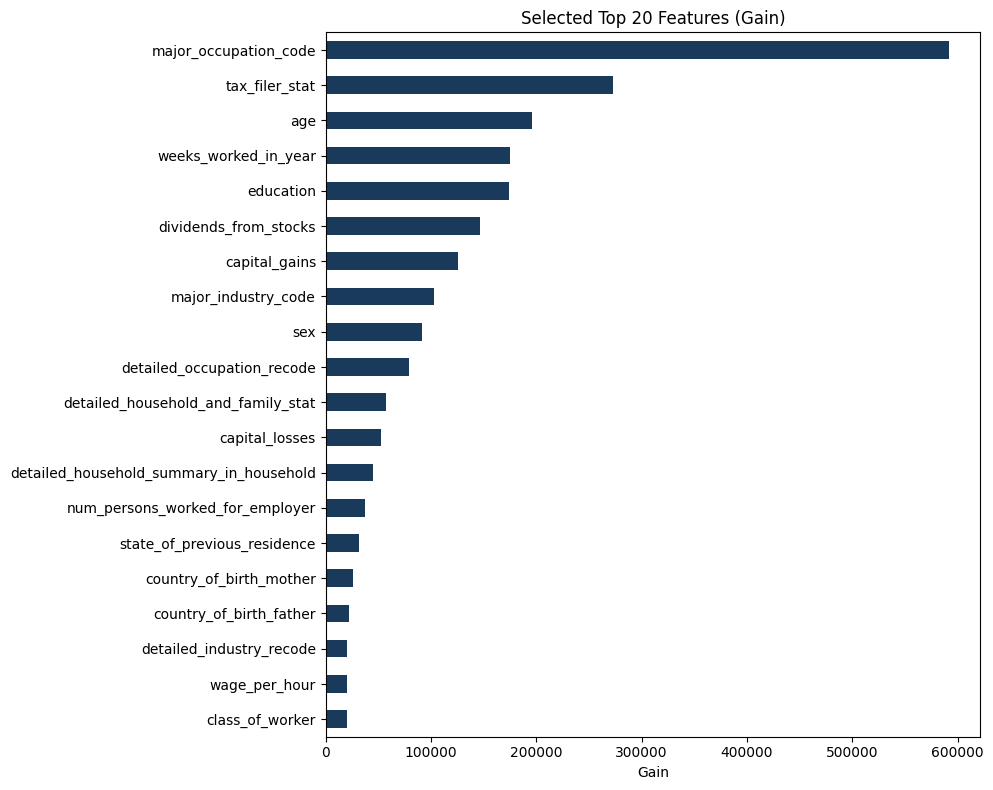

In [31]:

# Select top 20 features from baseline importance

FINAL_FEATURES = full_imp.head(20).index.tolist()
final_cat_cols = [c for c in FINAL_FEATURES if df[c].dtype.name == 'category']

print(f'Selected {len(FINAL_FEATURES)} features ({len(final_cat_cols)} categorical)\n')
for i, feat in enumerate(FINAL_FEATURES, 1):
    gain_pct = full_imp[feat] / full_imp.sum() * 100
    print(f'  {i:2d}. {feat:45s} ({gain_pct:.1f}%)')

print(f'\n→ Top 20: {full_imp.head(20).sum()/full_imp.sum()*100:.1f}% of total gain')
print(f'→ Dropped 16 features that contributed only {full_imp.tail(16).sum()/full_imp.sum()*100:.1f}%')

# Visualize selected features
fig, ax = plt.subplots(figsize=(10, 8))
selected_imp = full_imp.head(20).sort_values()
selected_imp.plot.barh(ax=ax, color='#1a3a5c')
ax.set_title('Selected Top 20 Features (Gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

##NOW WE CHOOSE THE TOP 20 FEATURES AND TRAIN OUR MODEL

In [32]:
# Train baseline model on top 20 features (default params)

X = df[FINAL_FEATURES]
y = df['label']

# Stratified splits
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=42
)

spw = (y_tr2 == 0).sum() / (y_tr2 == 1).sum()

print(f'Train: {X_tr2.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_te.shape[0]:,}')
print(f'scale_pos_weight: {spw:.2f}')

# Default params — NO tuning yet
default_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'lambda_l2': 1.0,
    'scale_pos_weight': spw,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
}

train_set = lgb.Dataset(X_tr2, label=y_tr2, categorical_feature=final_cat_cols)
val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=final_cat_cols, reference=train_set)

model = lgb.train(
    default_params,
    train_set,
    num_boost_round=2000,
    valid_sets=[train_set, val_set],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Val PR-AUC: {model.best_score["val"]["average_precision"]:.4f}')

Train: 133,393 | Val: 23,540 | Test: 39,234
scale_pos_weight: 14.84
Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.707882	val's average_precision: 0.649458
[200]	train's average_precision: 0.749728	val's average_precision: 0.659441
Early stopping, best iteration is:
[200]	train's average_precision: 0.749728	val's average_precision: 0.659441

Best iteration: 200
Val PR-AUC: 0.6594


In [33]:
# Evaluate baseline model on TEST set

proba_test = model.predict(X_te, num_iteration=model.best_iteration)

auc_test = roc_auc_score(y_te, proba_test)
ap_test = average_precision_score(y_te, proba_test)

# F1-optimal threshold
prec_te, rec_te, thr_te = precision_recall_curve(y_te, proba_test)
f1s_te = 2 * prec_te * rec_te / (prec_te + rec_te + 1e-9)
best_idx_te = np.argmax(f1s_te[:-1])
best_thr_te = thr_te[best_idx_te]
pred_test = (proba_test >= best_thr_te).astype(int)

print(f'=== Baseline Model — Test Set Results ===')
print(f'ROC-AUC:   {auc_test:.4f}')
print(f'PR-AUC:    {ap_test:.4f}')
print(f'Threshold: {best_thr_te:.3f}')
print(f'Precision: {precision_score(y_te, pred_test):.4f}')
print(f'Recall:    {recall_score(y_te, pred_test):.4f}')
print(f'F1:        {f1_score(y_te, pred_test):.4f}')
print(f'\n{classification_report(y_te, pred_test, target_names=["<50K", ">=50K"])}')

=== Baseline Model — Test Set Results ===
ROC-AUC:   0.9520
PR-AUC:    0.6752
Threshold: 0.854
Precision: 0.6074
Recall:    0.6248
F1:        0.6160

              precision    recall  f1-score   support

        <50K       0.97      0.97      0.97     36758
       >=50K       0.61      0.62      0.62      2476

    accuracy                           0.95     39234
   macro avg       0.79      0.80      0.79     39234
weighted avg       0.95      0.95      0.95     39234



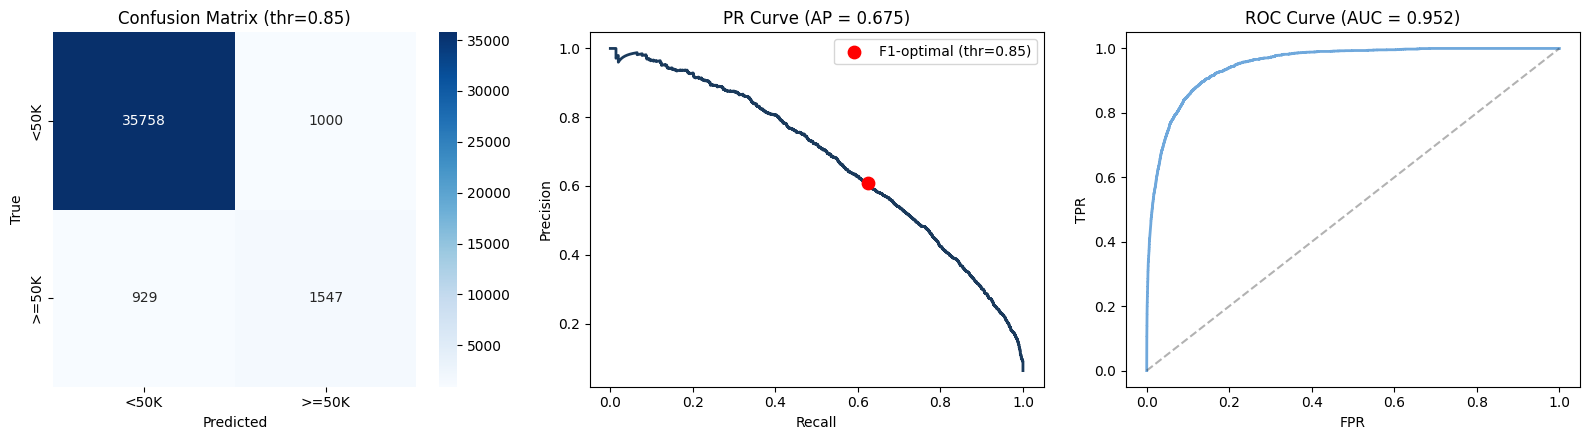

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix
cm = confusion_matrix(y_te, pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<50K', '>=50K'], yticklabels=['<50K', '>=50K'])
axes[0].set_title(f'Confusion Matrix (thr={best_thr_te:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# PR curve
axes[1].plot(rec_te, prec_te, color='#1a3a5c', lw=2)
axes[1].scatter([rec_te[best_idx_te]], [prec_te[best_idx_te]], c='red', s=80, zorder=5,
                label=f'F1-optimal (thr={best_thr_te:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve (AP = {ap_test:.3f})')
axes[1].legend()

# ROC curve
fpr_te, tpr_te, _ = roc_curve(y_te, proba_test)
axes[2].plot(fpr_te, tpr_te, color='#6fa8dc', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title(f'ROC Curve (AUC = {auc_test:.3f})')

plt.tight_layout()
plt.show()

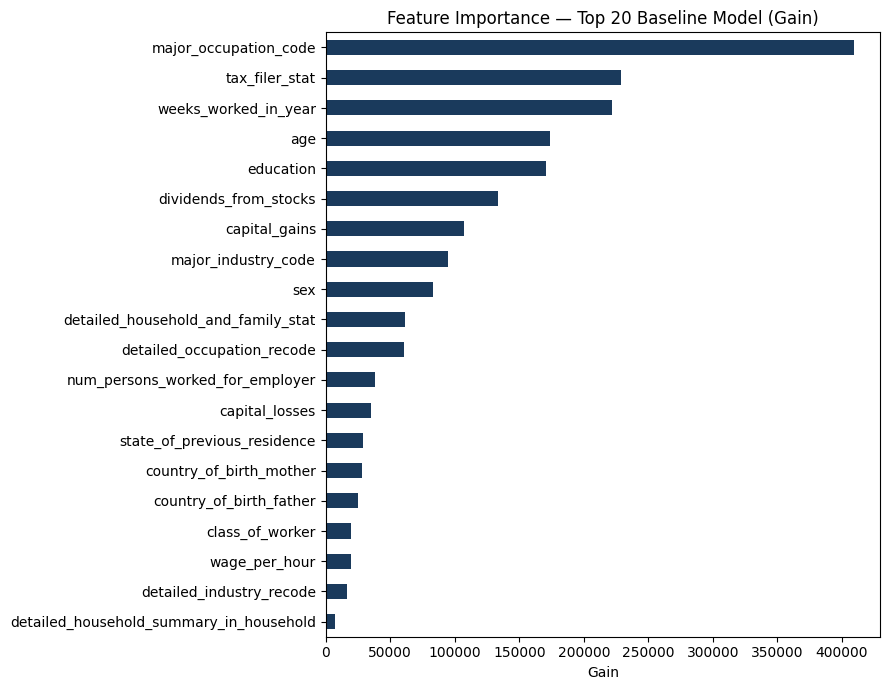

In [35]:
imp = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=FINAL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
imp.plot.barh(ax=ax, color='#1a3a5c')
ax.set_title('Feature Importance — Top 20 Baseline Model (Gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

##HYPER PARAMETER TUNING FOR THE MODEL WITH 20 FEATURES

In [ ]:
!pip install optuna

In [ ]:
# Optuna hyperparameter tuning on top 20 features

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    trial_params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'scale_pos_weight': spw,
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 500),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
    }

    ts = lgb.Dataset(X_tr2, label=y_tr2, categorical_feature=final_cat_cols)
    vs = lgb.Dataset(X_val, label=y_val, categorical_feature=final_cat_cols, reference=ts)

    m = lgb.train(
        trial_params, ts,
        num_boost_round=2000,
        valid_sets=[vs],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )

    proba_val = m.predict(X_val, num_iteration=m.best_iteration)
    return average_precision_score(y_val, proba_val)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest validation PR-AUC: {study.best_value:.4f}')
print(f'\nBest parameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

##NOW WE RETARIN THE MODEL WITH BEST OPTUNA PARAMETERS

In [38]:
# Retrain with Optuna's best params and evaluate on TEST set

tuned_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'scale_pos_weight': spw,
    **study.best_params,
}

ts_final = lgb.Dataset(X_tr2, label=y_tr2, categorical_feature=final_cat_cols)
vs_final = lgb.Dataset(X_val, label=y_val, categorical_feature=final_cat_cols, reference=ts_final)

model_tuned = lgb.train(
    tuned_params,
    ts_final,
    num_boost_round=3000,
    valid_sets=[ts_final, vs_final],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)


Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.673951	val's average_precision: 0.638567
[200]	train's average_precision: 0.708114	val's average_precision: 0.656469
[300]	train's average_precision: 0.725897	val's average_precision: 0.662391
[400]	train's average_precision: 0.737514	val's average_precision: 0.66514
[500]	train's average_precision: 0.74733	val's average_precision: 0.666591
[600]	train's average_precision: 0.756693	val's average_precision: 0.668129
[700]	train's average_precision: 0.765209	val's average_precision: 0.66954
Early stopping, best iteration is:
[744]	train's average_precision: 0.768684	val's average_precision: 0.669895


In [39]:
# Evaluate on TEST set
proba_tuned = model_tuned.predict(X_te, num_iteration=model_tuned.best_iteration)
auc_tuned = roc_auc_score(y_te, proba_tuned)
ap_tuned = average_precision_score(y_te, proba_tuned)

prec_t, rec_t, thr_t = precision_recall_curve(y_te, proba_tuned)
f1s_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-9)
best_idx_t = np.argmax(f1s_t[:-1])
best_thr_t = thr_t[best_idx_t]
pred_tuned = (proba_tuned >= best_thr_t).astype(int)

# Comparison table
comparison = pd.DataFrame({
    'Baseline (default)': [
        0.9520, 0.6752, 0.854, 0.6074, 0.6248, 0.6160
    ],
    'Tuned (Optuna)': [
        round(auc_tuned, 4),
        round(ap_tuned, 4),
        round(best_thr_t, 3),
        round(precision_score(y_te, pred_tuned), 4),
        round(recall_score(y_te, pred_tuned), 4),
        round(f1_score(y_te, pred_tuned), 4),
    ],
}, index=['ROC-AUC', 'PR-AUC', 'Threshold', 'Precision', 'Recall', 'F1'])

comparison['Change'] = comparison['Tuned (Optuna)'] - comparison['Baseline (default)']

print(f'Best iteration: {model_tuned.best_iteration}')
print(f'\n=== Baseline vs Tuned (Top 20 features) ===')
print(comparison)
print(f'\nPR-AUC change: {comparison.loc["PR-AUC", "Change"]:+.4f} ({comparison.loc["PR-AUC", "Change"]/0.6752*100:+.2f}%)')

Best iteration: 744

=== Baseline vs Tuned (Top 20 features) ===
           Baseline (default)  Tuned (Optuna)  Change
ROC-AUC                0.9520          0.9531  0.0011
PR-AUC                 0.6752          0.6861  0.0109
Threshold              0.8540          0.8660  0.0120
Precision              0.6074          0.6489  0.0415
Recall                 0.6248          0.6038 -0.0210
F1                     0.6160          0.6255  0.0095

PR-AUC change: +0.0109 (+1.61%)


Text(0.5, 20.222222222222214, 'Predicted')

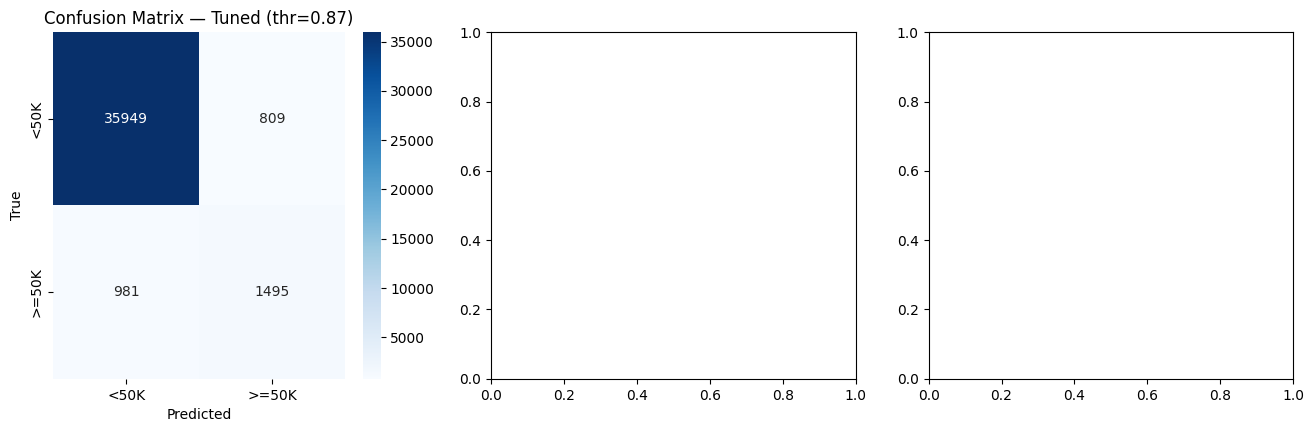

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix
cm_tuned = confusion_matrix(y_te, pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<50K', '>=50K'], yticklabels=['<50K', '>=50K'])
axes[0].set_title(f'Confusion Matrix — Tuned (thr={best_thr_t:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')



In [41]:
axes[1].plot(rec_t, prec_t, color='#1a3a5c', lw=2)
axes[1].scatter([rec_t[best_idx_t]], [prec_t[best_idx_t]], c='red', s=80, zorder=5,
                label=f'F1-optimal (thr={best_thr_t:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve (AP = {ap_tuned:.3f})')
axes[1].legend()

# ROC curve
fpr_t, tpr_t, _ = roc_curve(y_te, proba_tuned)
axes[2].plot(fpr_t, tpr_t, color='#6fa8dc', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title(f'ROC Curve (AUC = {auc_tuned:.3f})')

plt.tight_layout()
plt.show()

# Classification report
print(f'\n{classification_report(y_te, pred_tuned, target_names=["<50K", ">=50K"])}')

<Figure size 640x480 with 0 Axes>


              precision    recall  f1-score   support

        <50K       0.97      0.98      0.98     36758
       >=50K       0.65      0.60      0.63      2476

    accuracy                           0.95     39234
   macro avg       0.81      0.79      0.80     39234
weighted avg       0.95      0.95      0.95     39234



#SINCE WE HAVE 20 FEATURES IN THE PREVIOUS MODEL, NOW LETS TRY TO USE THE TOP 15 FEATURES AND SEE IF THE MODEL PERFORMS BETTER OR WORSE

In [ ]:
# ============================================================
# Optuna tuning on TOP 15 features
# ============================================================
TOP_15_FEATURES = full_imp.head(15).index.tolist()
top15_cat = [c for c in TOP_15_FEATURES if df[c].dtype.name == 'category']

print(f'Top 15 features ({len(top15_cat)} categorical):')
for i, f in enumerate(TOP_15_FEATURES, 1):
    print(f'  {i:2d}. {f}')

# Prepare data with top 15
X_15 = df[TOP_15_FEATURES]
y_15 = df['label']

X_tr_15, X_te_15, y_tr_15, y_te_15 = train_test_split(
    X_15, y_15, test_size=0.2, stratify=y_15, random_state=42
)
X_tr2_15, X_val_15, y_tr2_15, y_val_15 = train_test_split(
    X_tr_15, y_tr_15, test_size=0.15, stratify=y_tr_15, random_state=42
)

spw_15 = (y_tr2_15 == 0).sum() / (y_tr2_15 == 1).sum()

def objective_15(trial):
    trial_params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'scale_pos_weight': spw_15,
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 500),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
    }

    ts = lgb.Dataset(X_tr2_15, label=y_tr2_15, categorical_feature=top15_cat)
    vs = lgb.Dataset(X_val_15, label=y_val_15, categorical_feature=top15_cat, reference=ts)

    m = lgb.train(
        trial_params, ts,
        num_boost_round=2000,
        valid_sets=[vs],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )

    proba_val = m.predict(X_val_15, num_iteration=m.best_iteration)
    return average_precision_score(y_val_15, proba_val)

study_15 = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
)
study_15.optimize(objective_15, n_trials=50, show_progress_bar=True)

print(f'\nBest validation PR-AUC: {study_15.best_value:.4f}')
print(f'\nBest parameters:')
for k, v in study_15.best_params.items():
    print(f'  {k}: {v}')

In [43]:
# ============================================================
# Retrain top 15 with Optuna params and evaluate on TEST
# ============================================================
tuned_params_15 = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'scale_pos_weight': spw_15,
    **study_15.best_params,
}

ts_15 = lgb.Dataset(X_tr2_15, label=y_tr2_15, categorical_feature=top15_cat)
vs_15 = lgb.Dataset(X_val_15, label=y_val_15, categorical_feature=top15_cat, reference=ts_15)

model_tuned_15 = lgb.train(
    tuned_params_15, ts_15,
    num_boost_round=3000,
    valid_sets=[ts_15, vs_15],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)




Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.713117	val's average_precision: 0.653183
[200]	train's average_precision: 0.744467	val's average_precision: 0.660163
Early stopping, best iteration is:
[232]	train's average_precision: 0.751422	val's average_precision: 0.660751


In [44]:
# Evaluate on test set
proba_15 = model_tuned_15.predict(X_te_15, num_iteration=model_tuned_15.best_iteration)
auc_15 = roc_auc_score(y_te_15, proba_15)
ap_15 = average_precision_score(y_te_15, proba_15)

prec_15, rec_15, thr_15 = precision_recall_curve(y_te_15, proba_15)
f1s_15 = 2 * prec_15 * rec_15 / (prec_15 + rec_15 + 1e-9)
best_idx_15 = np.argmax(f1s_15[:-1])
best_thr_15 = thr_15[best_idx_15]
pred_15 = (proba_15 >= best_thr_15).astype(int)

print(f'Best iteration: {model_tuned_15.best_iteration}')
print(f'\n=== Top 15 Tuned — Test Set Results ===')
print(f'ROC-AUC:   {auc_15:.4f}')
print(f'PR-AUC:    {ap_15:.4f}')
print(f'Threshold: {best_thr_15:.3f}')
print(f'Precision: {precision_score(y_te_15, pred_15):.4f}')
print(f'Recall:    {recall_score(y_te_15, pred_15):.4f}')
print(f'F1:        {f1_score(y_te_15, pred_15):.4f}')


Best iteration: 232

=== Top 15 Tuned — Test Set Results ===
ROC-AUC:   0.9502
PR-AUC:    0.6738
Threshold: 0.842
Precision: 0.5983
Recall:    0.6426
F1:        0.6197


In [45]:
# Three-way comparison
comparison_all = pd.DataFrame({
    'Baseline 20': [
        0.9520, 0.6752, 0.854, 0.6074, 0.6248, 0.6160
    ],
    'Tuned 20': [
        round(auc_tuned, 4), round(ap_tuned, 4), round(best_thr_t, 3),
        round(precision_score(y_te, pred_tuned), 4),
        round(recall_score(y_te, pred_tuned), 4),
        round(f1_score(y_te, pred_tuned), 4),
    ],
    'Tuned 15': [
        round(auc_15, 4), round(ap_15, 4), round(best_thr_15, 3),
        round(precision_score(y_te_15, pred_15), 4),
        round(recall_score(y_te_15, pred_15), 4),
        round(f1_score(y_te_15, pred_15), 4),
    ],
}, index=['ROC-AUC', 'PR-AUC', 'Threshold', 'Precision', 'Recall', 'F1'])

print(f'\n=== Three-way comparison ===')
print(comparison_all)


=== Three-way comparison ===
           Baseline 20  Tuned 20  Tuned 15
ROC-AUC         0.9520    0.9531    0.9502
PR-AUC          0.6752    0.6861    0.6738
Threshold       0.8540    0.8660    0.8420
Precision       0.6074    0.6489    0.5983
Recall          0.6248    0.6038    0.6426
F1              0.6160    0.6255    0.6197


Text(0.5, 20.222222222222214, 'Predicted')

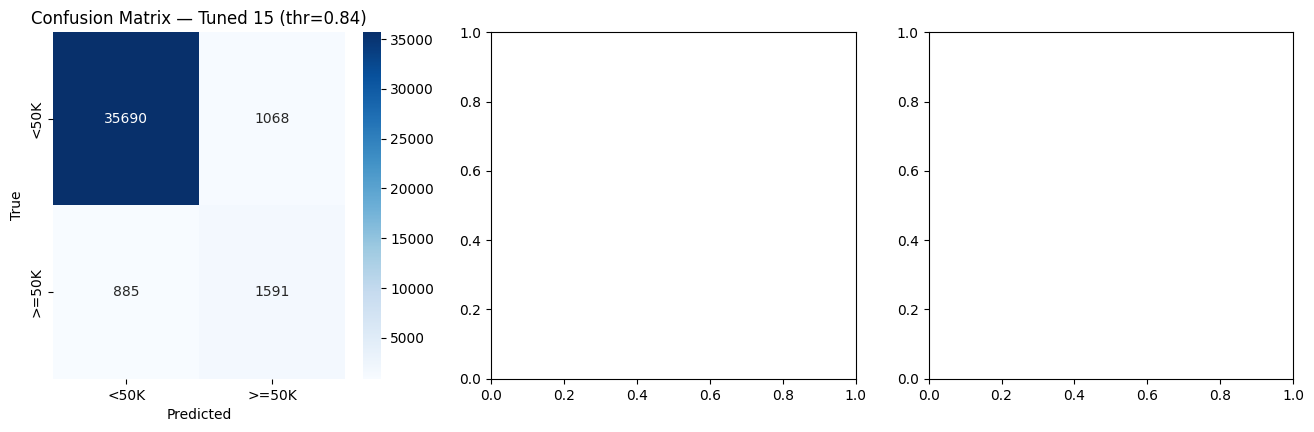

In [46]:
# ============================================================
# Tuned 15 Features — Diagnostic Plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix
cm_15 = confusion_matrix(y_te_15, pred_15)
sns.heatmap(cm_15, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<50K', '>=50K'], yticklabels=['<50K', '>=50K'])
axes[0].set_title(f'Confusion Matrix — Tuned 15 (thr={best_thr_15:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

In [47]:


# PR curve
axes[1].plot(rec_15, prec_15, color='#1a3a5c', lw=2)
axes[1].scatter([rec_15[best_idx_15]], [prec_15[best_idx_15]], c='red', s=80, zorder=5,
                label=f'F1-optimal (thr={best_thr_15:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve (AP = {ap_15:.3f})')
axes[1].legend()

# ROC curve
fpr_15, tpr_15, _ = roc_curve(y_te_15, proba_15)
axes[2].plot(fpr_15, tpr_15, color='#6fa8dc', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title(f'ROC Curve (AUC = {auc_15:.3f})')

plt.tight_layout()
plt.show()

# Print breakdown
tn, fp, fn, tp = cm_15.ravel()
print(f'=== Tuned 15 — Confusion Matrix Breakdown ===')
print(f'True Negatives  (correct <50K):    {tn:,}')
print(f'True Positives  (correct >=50K):   {tp:,}')
print(f'False Positives (flagged but <50K): {fp:,}')
print(f'False Negatives (missed >=50K):     {fn:,}')

print(f'\n=== Tuned 15 — Summary ===')
print(f'PR-AUC:    {ap_15:.4f}')
print(f'Precision: {precision_score(y_te_15, pred_15):.4f}')
print(f'Recall:    {recall_score(y_te_15, pred_15):.4f}')
print(f'F1:        {f1_score(y_te_15, pred_15):.4f}')

<Figure size 640x480 with 0 Axes>

=== Tuned 15 — Confusion Matrix Breakdown ===
True Negatives  (correct <50K):    35,690
True Positives  (correct >=50K):   1,591
False Positives (flagged but <50K): 1,068
False Negatives (missed >=50K):     885

=== Tuned 15 — Summary ===
PR-AUC:    0.6738
Precision: 0.5983
Recall:    0.6426
F1:        0.6197


WE CAN OBSERVE THAT THE 15 FEATURE MODEL DIDNT PERFORM WELL WHEN COMPARED TO THE 20 FEATURE MODEL

So finally save the model with 20 features and Optuna tuned

In [48]:
import pickle
import pandas as pd

# Save the trained model
with open('lightgbm_model.pkl', 'wb') as f:
    pickle.dump(model_tuned, f)

# Save the full cleaned dataset with predictions
df['income_probability'] = model_tuned.predict(df[FINAL_FEATURES])
df.to_csv('df_with_predictions.csv', index=False)

print("Model and predictions saved!")

# If on Google Colab download them
from google.colab import files
files.download('lightgbm_model.pkl')
files.download('df_with_predictions.csv')

Model and predictions saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>